In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Landslide_dataset.csv")

df.head()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
0,206.181018,58.275001,0.892798,0.339463,4.390047,0.099975,1,0,0,0
1,218.887334,36.679801,0.657147,0.360355,4.141029,0.832443,1,0,0,1
2,181.850867,31.363874,0.673362,0.221697,5.311891,0.023062,1,0,0,1
3,228.716199,38.995134,0.618666,0.489502,4.581928,0.785176,1,0,0,1
4,179.951067,42.998205,0.836966,0.118580,5.518862,0.450499,1,0,0,0


In [4]:
# shape and data types
print(df.shape)
df.info()

# missing values
print(df.isnull().sum())

# class balance
print(df['Landslide'].value_counts())
print(df['Landslide'].value_counts(normalize=True))

(2000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rainfall_mm          2000 non-null   float64
 1   Slope_Angle          2000 non-null   float64
 2   Soil_Saturation      2000 non-null   float64
 3   Vegetation_Cover     2000 non-null   float64
 4   Earthquake_Activity  2000 non-null   float64
 5   Proximity_to_Water   2000 non-null   float64
 6   Landslide            2000 non-null   int64  
 7   Soil_Type_Gravel     2000 non-null   int64  
 8   Soil_Type_Sand       2000 non-null   int64  
 9   Soil_Type_Silt       2000 non-null   int64  
dtypes: float64(6), int64(4)
memory usage: 156.4 KB
Rainfall_mm            0
Slope_Angle            0
Soil_Saturation        0
Vegetation_Cover       0
Earthquake_Activity    0
Proximity_to_Water     0
Landslide              0
Soil_Type_Gravel       0
Soil_Type_Sand         0
Soil_Type_Silt  

In [5]:
df.describe()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.0000,2000.00000
mean,176.688462,29.985404,0.540316,0.522862,3.604771,1.001867,0.500000,0.25850,0.2415,0.26100
std,65.724685,15.175902,0.295665,0.260426,1.895955,0.579964,0.500125,0.43792,0.4281,0.43929
min,50.036151,5.003944,0.000652,0.100005,0.001641,0.000653,0.000000,0.00000,0.0000,0.00000
25%,128.379762,18.018061,0.265634,0.295475,1.973415,0.500808,0.000000,0.00000,0.0000,0.00000
50%,177.013773,27.772833,0.599887,0.500191,3.996429,0.999761,0.500000,0.00000,0.0000,0.00000
75%,228.742286,41.683190,0.801994,0.740690,5.233897,1.505294,1.000000,1.00000,0.0000,1.00000
max,299.919102,59.966732,0.998831,0.999837,6.498670,1.999636,1.000000,1.00000,1.0000,1.00000


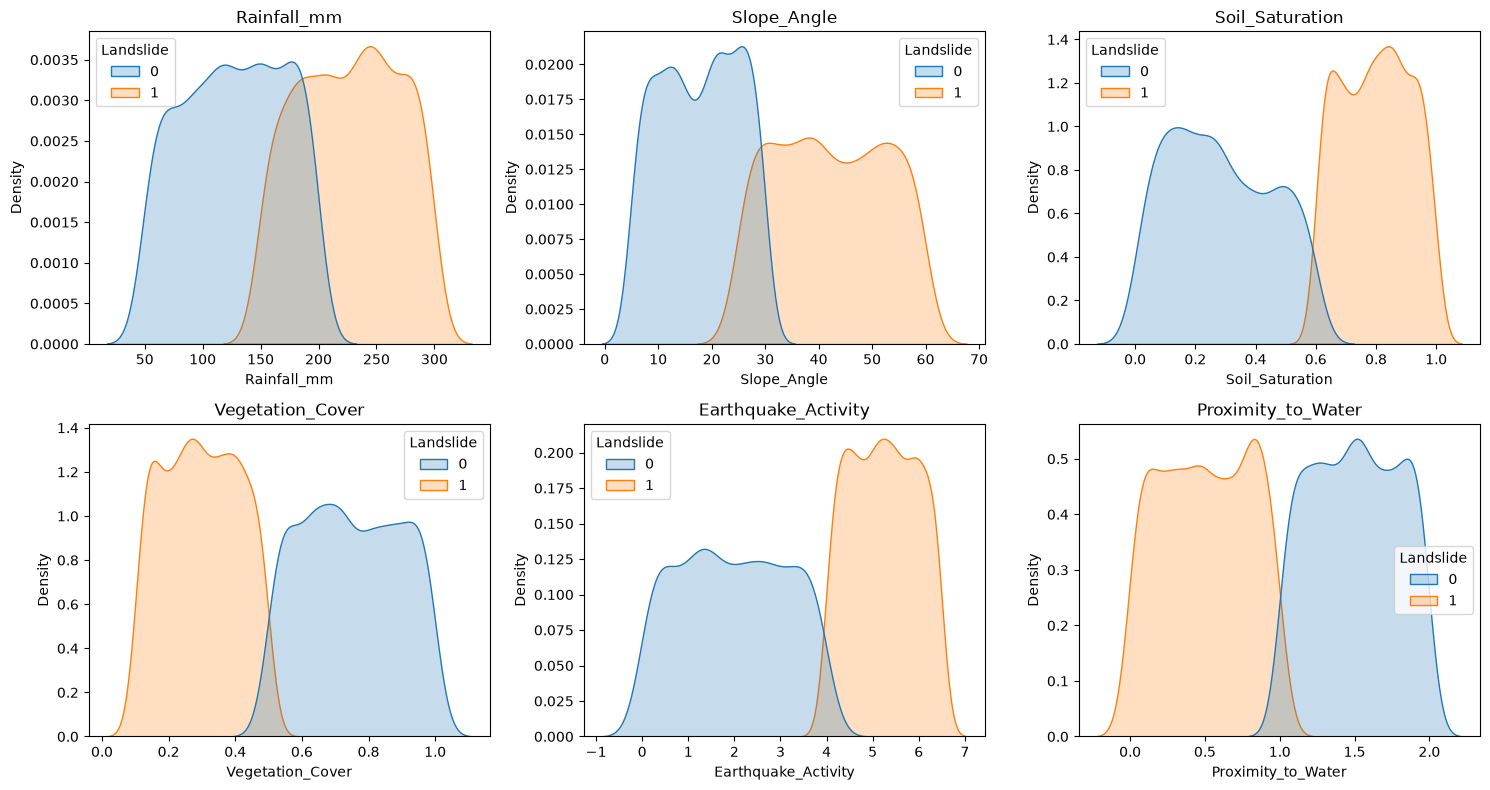

In [6]:

features = ['Rainfall_mm', 'Slope_Angle', 'Soil_Saturation', 'Vegetation_Cover', 'Earthquake_Activity', 'Proximity_to_Water']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Landslide', ax=axes[i], fill=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

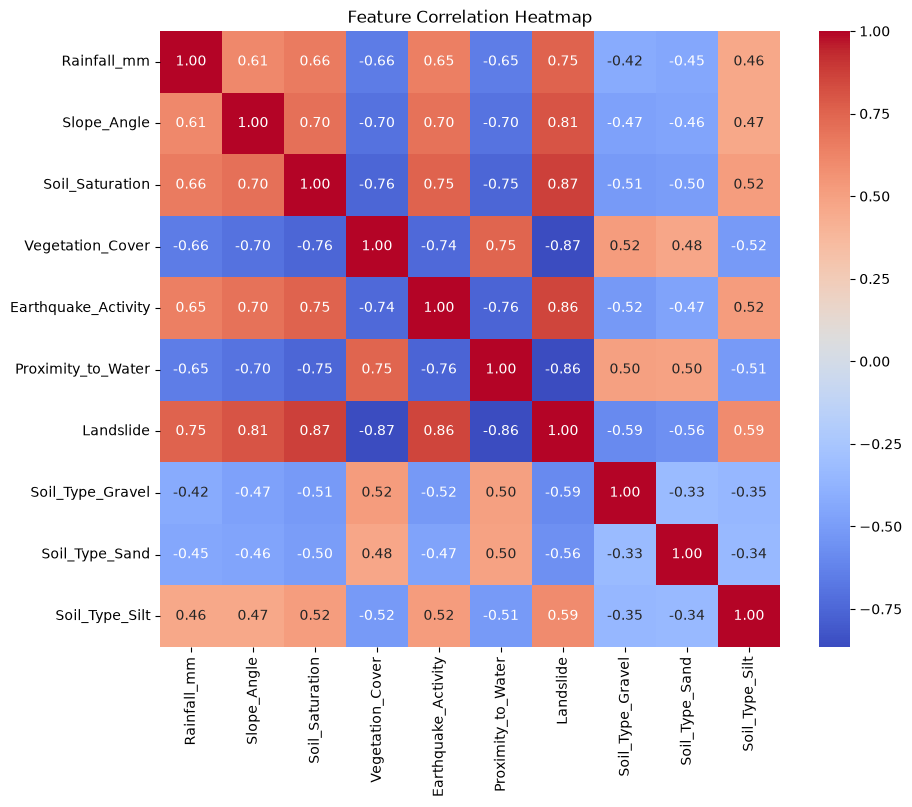

In [7]:
# correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

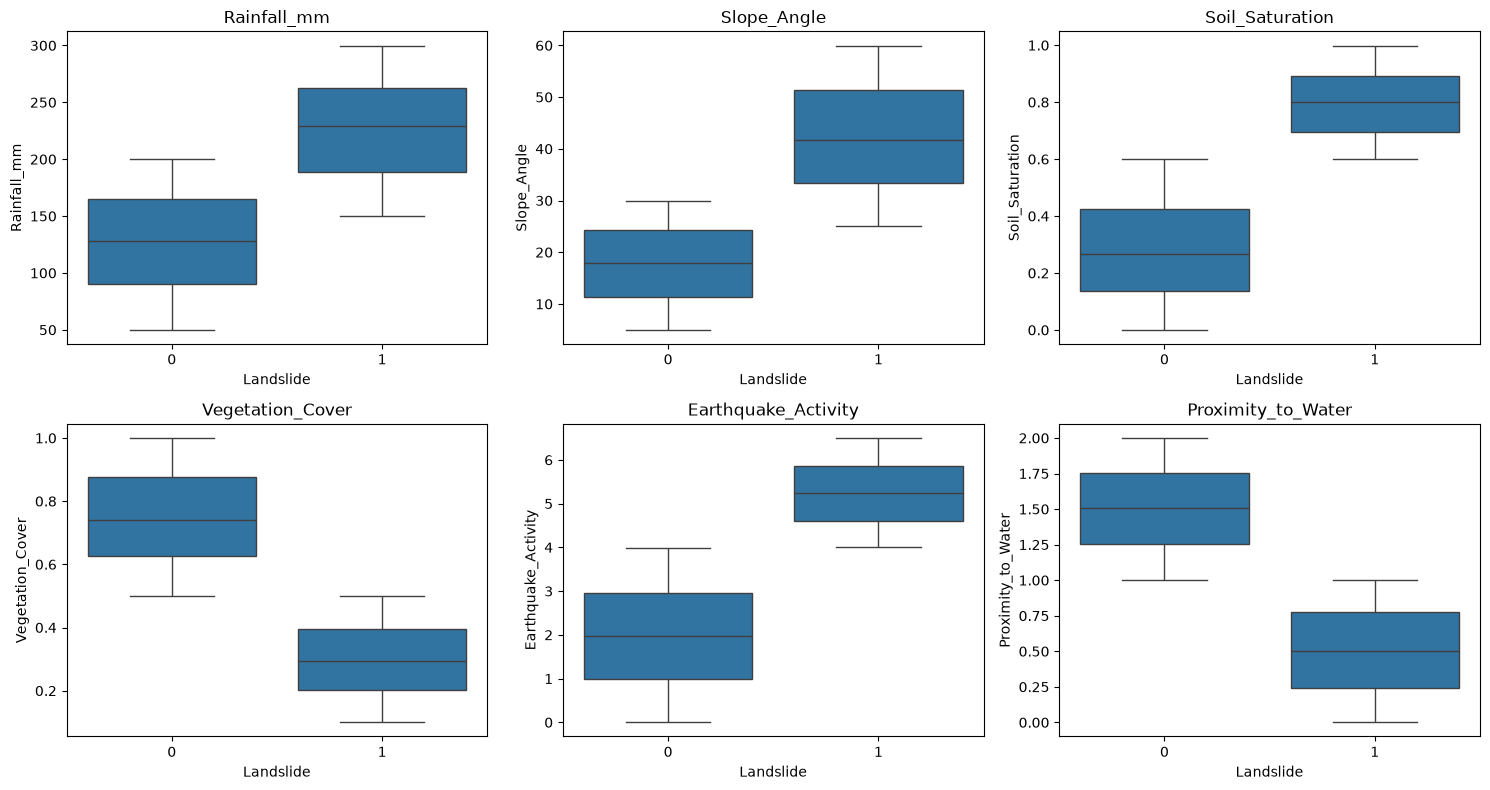

In [19]:
# boxplots to visually spot outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Landslide', y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [20]:

def count_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers)

for col in features:
    n_outliers = count_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers")

Rainfall_mm: 0 outliers
Slope_Angle: 0 outliers
Soil_Saturation: 0 outliers
Vegetation_Cover: 0 outliers
Earthquake_Activity: 0 outliers
Proximity_to_Water: 0 outliers


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Landslide', axis=1)
y = df['Landslide']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(1600, 9) (400, 9)
Landslide
1    800
0    800
Name: count, dtype: int64
Landslide
0    200
1    200
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Confusion Matrix:
 [[200   0]
 [  0 200]]


In [11]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)  
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



<Figure size 600x500 with 0 Axes>

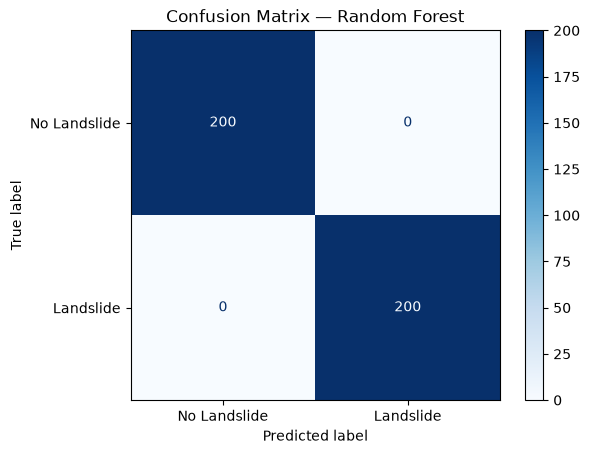

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Landslide', 'Landslide'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Random Forest')
plt.show()

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

Soil_Saturation        0.310000
Vegetation_Cover       0.241984
Earthquake_Activity    0.210229
Proximity_to_Water     0.184838
Slope_Angle            0.033287
Rainfall_mm            0.015908
Soil_Type_Silt         0.003728
Soil_Type_Gravel       0.000025
Soil_Type_Sand         0.000000
dtype: float64


In [15]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results.append({"Model": name, "Test Accuracy": acc, "CV Mean Accuracy": cv})

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
print(results_df)

                 Model  Test Accuracy  CV Mean Accuracy
0  Logistic Regression            1.0               1.0
1        Decision Tree            1.0               1.0
2        Random Forest            1.0               1.0
3    Gradient Boosting            1.0               1.0
4                  SVM            1.0               1.0
5                  KNN            1.0               1.0
6          Naive Bayes            1.0               1.0


Shallow tree (depth=3) accuracy: 1.0


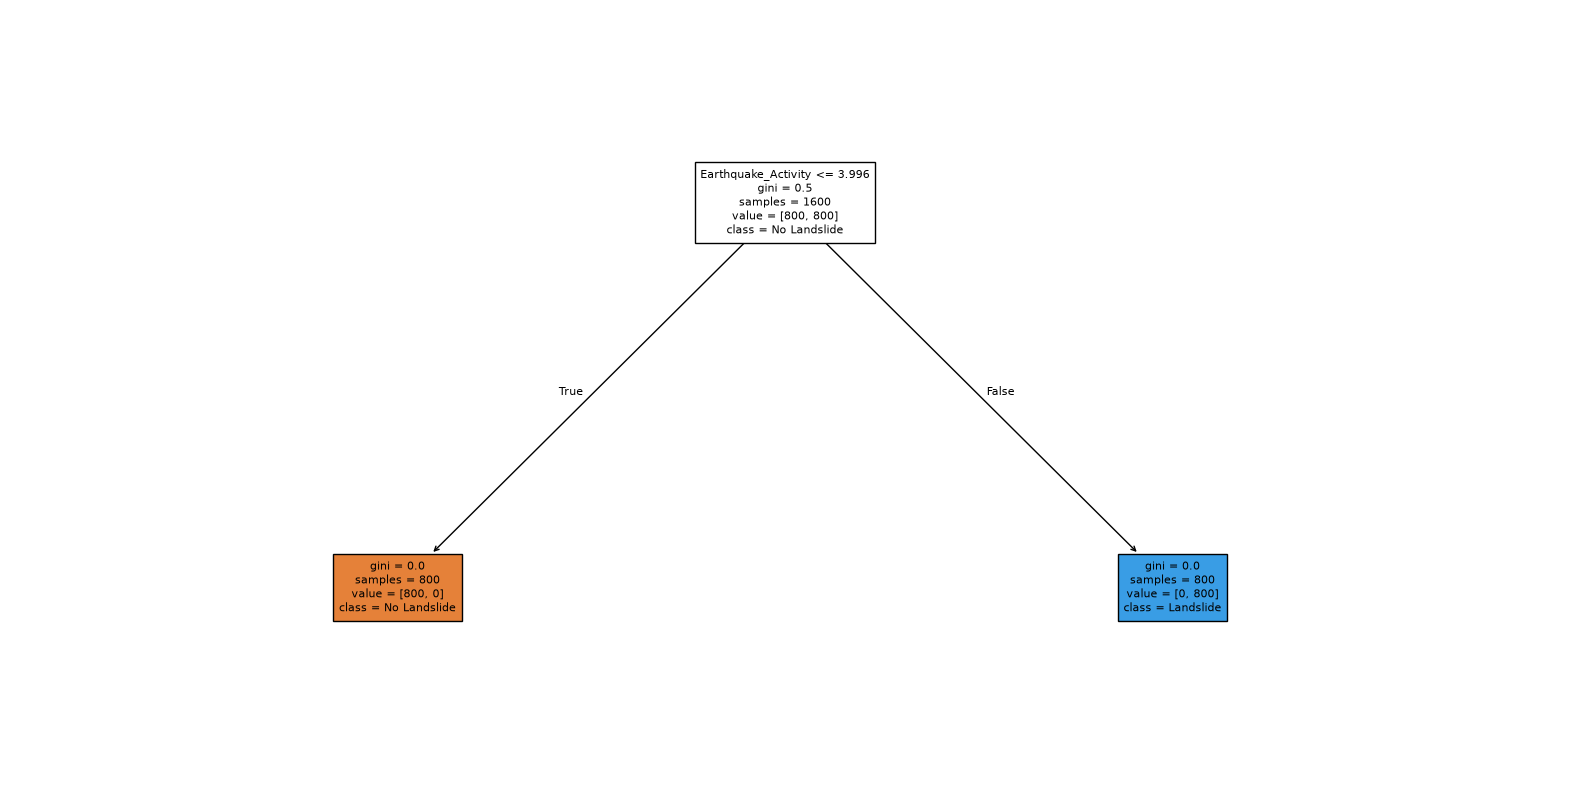

In [16]:

from sklearn.tree import DecisionTreeClassifier, plot_tree

shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)
print("Shallow tree (depth=3) accuracy:", accuracy_score(y_test, shallow_tree.predict(X_test)))

plt.figure(figsize=(20, 10))
plot_tree(shallow_tree, feature_names=X.columns, class_names=['No Landslide', 'Landslide'], filled=True, fontsize=8)
plt.show()

## Summary

- Dataset: 2000 samples, 9 features (rainfall, slope angle, soil saturation, 
  vegetation cover, earthquake activity, proximity to water, soil type), 
  perfectly balanced target (50% landslide / 50% no landslide).
- No missing values.
- Correlation analysis showed strong relationships between all features and 
  the target (0.75–0.87), consistent with known landslide risk factors.
- Tested 7 classification algorithms (Logistic Regression, Decision Tree, 
  Random Forest, Gradient Boosting, SVM, KNN, Naive Bayes) — all achieved 
  100% test accuracy and 100% mean cross-validation accuracy.
- This indicates the dataset is synthetically generated with a clean 
  underlying rule linking these features to landslide occurrence, rather 
  than noisy real-world sensor data.
- Feature importance (Random Forest) ranked Soil_Saturation, 
  Vegetation_Cover, Earthquake_Activity, and Proximity_to_Water as the 
  strongest predictors — consistent with established landslide geotechnics.
